In [1]:
# ============================================
# ✅ IMPORTS
# ============================================
import torch
import torch.nn as nn
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# ============================================
# ✅ SETTINGS
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

resize = 224
INIT_LR = 1e-4
EPOCHS = 25
FT_EPOCHS = 10
BS = 32

base_dir = "SkinType_Dataset"
TRAIN_DIR = os.path.join(base_dir, "train")
VALID_DIR = os.path.join(base_dir, "valid")
TEST_DIR  = os.path.join(base_dir, "test")

for d in [TRAIN_DIR, VALID_DIR, TEST_DIR]:
    assert os.path.exists(d), f"❌ Folder missing: {d}"

categories = sorted(os.listdir(TRAIN_DIR))
print("Classes:", categories)

Using: cuda
Classes: ['Dry', 'Normal', 'Oily']


In [3]:
# ============================================
# ✅ TRANSFORMS (same as before)
# ============================================
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

train_tf = transforms.Compose([
    transforms.Resize((resize, resize)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(resize),
    transforms.ToTensor(),
    normalize
])

test_tf = transforms.Compose([
    transforms.Resize((resize, resize)),
    transforms.ToTensor(),
    normalize
])

In [4]:
# ============================================
# ✅ DATA LOADERS
# ============================================
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
valid_ds = datasets.ImageFolder(VALID_DIR, transform=test_tf)
test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tf)

train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BS, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BS, shuffle=False)

In [5]:
# ============================================
# ✅ CLASS WEIGHTS (for imbalance)
# ============================================
labels = [label for _, label in train_ds.samples]
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class Weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

Class Weights: tensor([1., 1., 1.], device='cuda:0')


In [6]:
# ============================================
# ✅ MODEL — EfficientNet-B0
# ============================================
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 3)  # 3 classes
model = model.to(device)

# ✅ Freeze backbone initially
for name, param in model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

optimizer = torch.optim.Adam(model.classifier.parameters(), lr=INIT_LR)

In [7]:
# ============================================
# ✅ TRAINING STAGE 1 — train classifier only
# ============================================
print("\n✅ Training Stage 1...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {total_loss/len(train_loader):.4f}")


✅ Training Stage 1...
Epoch [1/25] Loss: 1.0891
Epoch [2/25] Loss: 1.0425
Epoch [3/25] Loss: 0.9962
Epoch [4/25] Loss: 0.9583
Epoch [5/25] Loss: 0.9350
Epoch [6/25] Loss: 0.9077
Epoch [7/25] Loss: 0.8779
Epoch [8/25] Loss: 0.8517
Epoch [9/25] Loss: 0.8565
Epoch [10/25] Loss: 0.8410
Epoch [11/25] Loss: 0.8220
Epoch [12/25] Loss: 0.8013
Epoch [13/25] Loss: 0.7900
Epoch [14/25] Loss: 0.7842
Epoch [15/25] Loss: 0.7827
Epoch [16/25] Loss: 0.7605
Epoch [17/25] Loss: 0.7901
Epoch [18/25] Loss: 0.7435
Epoch [19/25] Loss: 0.7507
Epoch [20/25] Loss: 0.7522
Epoch [21/25] Loss: 0.7338
Epoch [22/25] Loss: 0.7566
Epoch [23/25] Loss: 0.7423
Epoch [24/25] Loss: 0.7450
Epoch [25/25] Loss: 0.7295


In [8]:
# ============================================
# ✅ STAGE 2 — unfreeze entire model (fine-tune)
# ============================================
print("\n✅ Fine-tuning...")
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

best_acc = 0
for epoch in range(FT_EPOCHS):
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"FineTune Epoch [{epoch+1}/{FT_EPOCHS}] Loss: {total_loss/len(train_loader):.4f}")

    # ✅ Validation check
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            pred = torch.argmax(out, dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Validation Accuracy: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "efficientnet_skin_classifier.pth")
        print("✅ Saved best model!")


✅ Fine-tuning...
FineTune Epoch [1/10] Loss: 0.7159
Validation Accuracy: 0.6522
✅ Saved best model!
FineTune Epoch [2/10] Loss: 0.6838
Validation Accuracy: 0.6957
✅ Saved best model!
FineTune Epoch [3/10] Loss: 0.6595
Validation Accuracy: 0.6957
FineTune Epoch [4/10] Loss: 0.6385
Validation Accuracy: 0.6522
FineTune Epoch [5/10] Loss: 0.6262
Validation Accuracy: 0.6957
FineTune Epoch [6/10] Loss: 0.6025
Validation Accuracy: 0.7391
✅ Saved best model!
FineTune Epoch [7/10] Loss: 0.5942
Validation Accuracy: 0.8261
✅ Saved best model!
FineTune Epoch [8/10] Loss: 0.5533
Validation Accuracy: 0.8696
✅ Saved best model!
FineTune Epoch [9/10] Loss: 0.5785
Validation Accuracy: 0.7826
FineTune Epoch [10/10] Loss: 0.5277
Validation Accuracy: 0.7826



✅ Testing...
              precision    recall  f1-score   support

         Dry       0.86      0.75      0.80         8
      Normal       0.89      0.80      0.84        10
        Oily       0.75      0.90      0.82        10

    accuracy                           0.82        28
   macro avg       0.83      0.82      0.82        28
weighted avg       0.83      0.82      0.82        28



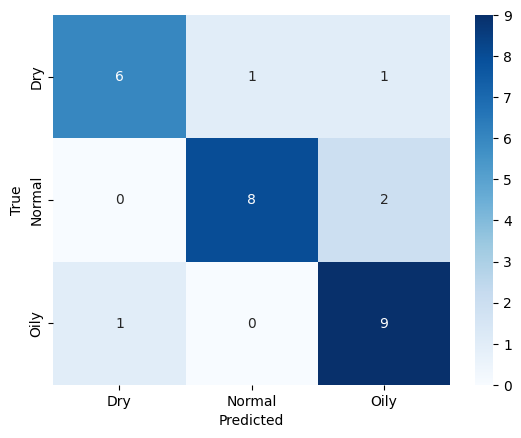

✅ Training complete! Model saved as efficientnet_skin_classifier.pth


In [9]:
# ============================================
# ✅ TESTING
# ============================================
print("\n✅ Testing...")
model.eval()
all_preds, all_tgts = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        out = model(imgs)
        preds = torch.argmax(out, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_tgts.extend(labels.numpy())

print(classification_report(all_tgts, all_preds, target_names=categories))

cm = confusion_matrix(all_tgts, all_preds)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("✅ Training complete! Model saved as efficientnet_skin_classifier.pth")